<a href="https://colab.research.google.com/github/iestleija/4808-Programacion/blob/Unidad3/Unidad3/Practices/266229_03_semana11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Maestría en Inteligencia Artificial y Analítica de Datos

## Programación para Analítica Descriptiva y Predictiva - Marzo 2025
## Práctica: Regresión Lasso y Ridge
---


## Datos del Estudiante

*   Apellidos y Nombre: Ismael Estrada Leija
*   Matrícula: 266229

---


### **Instrucciones y Objetivos para la Práctica: Regresión Lasso y Ridge**

#### **📌 Objetivos de la Práctica:**  
Al finalizar esta práctica, los estudiantes serán capaces de:  
1. **Realizar un Análisis Exploratorio de Datos (EDA)** completo, incluyendo visualización de distribuciones, detección de outliers y análisis de correlaciones.  
2. **Preprocesar datos** correctamente, manejando valores faltantes, codificando variables categóricas y escalando características.  
3. **Implementar modelos de regresión Lasso y Ridge**, entendiendo cómo la regularización afecta los coeficientes.  
4. **Verificar los supuestos de la regresión lineal** (linealidad, normalidad de residuos, homocedasticidad y multicolinealidad).  
5. **Comparar el rendimiento** de ambos modelos y analizar qué variables son más relevantes en cada caso.  

---

### **📋 Instrucciones**  

#### **🔹 Paso 1: Configuración Inicial**
✅ Carga el set de datos que puedes encontrar en el campus virtual
✅ Ejecutar las celdas de importación de librerías y carga del dataset.  
✅ Familiarizarse con los datos usando `.head()`, `.info()` y `.describe()`.  

#### **🔹 Paso 2: Análisis Exploratorio (EDA)**  
📊 **Para variables numéricas:**  
- Generar histogramas y boxplots para identificar distribuciones y outliers.  
- Calcular medidas de tendencia central y dispersión.  

📊 **Para variables categóricas:**  
- Usar gráficos de barras para visualizar frecuencias.    

#### **🔹 Paso 3: Matriz de Correlación**  
✅ Calcular la matriz de correlación **solo para variables numéricas**.  
✅ Generar un **mapa de calor** para visualizar relaciones.  
📌 **Pregunta:** ¿Qué variables están más correlacionadas con el target (`charges`)?  

#### **🔹 Paso 4: Preprocesamiento**  
🔧 **Tareas:**  
1. Manejar valores faltantes con `SimpleImputer`.  
2. Codificar variables categóricas con `OneHotEncoder`.  
3. Estandarizar variables numéricas con `StandardScaler`.  
✅ Verificar que el dataset transformado no tenga valores nulos.  

#### **🔹 Paso 5: Modelado (Lasso y Ridge)**  
🎯 **Para cada modelo:**  
1. Ajustar el modelo con los hiperparámetros dados (`alpha=0.1` para Lasso, `alpha=1.0` para Ridge).  
2. Calcular **MSE** y **R²** para evaluar rendimiento.  
3. Analizar los coeficientes para identificar variables importantes.  

📌 **Pregunta:**  
- ¿Qué modelo tiene un mejor R²? ¿Por qué crees que ocurre esto?  
- ¿Qué variables tienen coeficientes cercanos a cero en Lasso? ¿Por qué?  

#### **🔹 Paso 6: Verificación de Supuestos**  
📉 **Para cada modelo, verificar:**  
1. **Linealidad** (gráfico de residuos vs predicciones).  
2. **Normalidad de residuos** (QQ-Plot y test de Shapiro-Wilk).  
3. **Homocedasticidad** (test de Breusch-Pagan).  
4. **Multicolinealidad** (VIF > 10 indica problema).  

📌 **Pregunta:**  
- ¿Se cumplen los supuestos en ambos modelos?  
- Si hay heterocedasticidad, ¿cómo podría solucionarse?  

#### **🔹 Paso 7: Comparación Final**  
📊 **Analizar:**  
- ¿Qué modelo es más interpretable?  
- ¿Cuál reduce mejor el sobreajuste?  
- ¿Qué variables son más importantes en cada caso?  

---

### **📌 Entrega de la Práctica**  
Al finalizar la practica, incluye un texto con los siguientes elementos
- Incluir **comentarios explicativos** en cada paso.  
- Responder las **preguntas planteadas** en celdas Markdown.  

🎯 **Criterios de Evaluación:**  
✔ **Correcto preprocesamiento** (manejo de nulos, escalado, encoding).  
✔ **Análisis visual y estadístico** (gráficos claros, interpretación de resultados).  
✔ **Validación de supuestos** (justificación de si se cumplen o no).  
✔ **Comparación crítica** entre Lasso y Ridge.  

## **🔹 Paso 1: Configuración Inicial**
✅ Carga el set de datos que puedes encontrar en el campus virtual

✅ Ejecutar las celdas de importación de librerías y carga del dataset.  
✅ Familiarizarse con los datos usando `.head()`, `.info()` y `.describe()`.  


In [88]:
from google.colab import drive
drive.mount('/content/drive')
def print_bold(msg):
    print("\n\033[1m" + msg + "\033[0m")
path_to_file="/content/drive/MyDrive/4808-programacion/semana11/Practica03/insurance.csv"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Nota: Configuración
Se realiza el montaje de google drive en donde se ha almacenado el conjunto de datos proporcionado. Se guarda la ruta a ese archivo en la variable  `path_to_file`

In [89]:
import pandas as pd

df = pd.read_csv(path_to_file)
print_bold("Primeras filas del conjunto de datos")
display(df.head())





Primeras filas del conjunto de datos


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90000,0,yes,southwest,16884.92400
1,18,male,33.77000,1,no,southeast,1725.55230
2,28,male,33.00000,3,no,southeast,4449.46200
3,33,male,22.70500,0,no,northwest,21984.47061
4,32,male,28.88000,0,no,northwest,3866.85520


##Nota: Carga de datos
Se carga el conjunto de datos en un dataframe de pandas y se despliegan las filas iniciales del mismo usando la cantidad por omisión de 5.
El dataframe muestra 7 columnas de datos, de los cuales edad, índice de masa corporal, cantidad de hijos y cargos, aparecen como valoers numericos; por su parte género, fumador, y región podrían considerarse valores categóricos.

In [90]:
print_bold("Estructura del DF")
display(df.info())
translated_names = {
    'age': 'Edad',
    'sex': 'Género',
    'bmi': 'IMC',
    'children': 'Hijos',
    'smoker': 'Fumador',
    'region': 'Región',
    'charges': 'Cargos',
    'male': 'Masculino',
    'female': 'Femenino',
    'yes': 'Sí',
    'no': 'No',
    'northeast': 'Noreste',
    'northwest': 'Noroeste',
    'southeast': 'Sureste',
    'southwest': 'Suroeste'
}



Estructura del DF
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


None

##Nota: Estructura de los datos
La estructura descrita del dataframe nos muestra 7 características con reporte de ningún dato faltante en la totalidad de columnas. Por su parte el tipo de datos esta mezclado como lo muestra la siguiente tabla y se recomienda el ajuste de tipo de datos a categórico para tres variables, enumerativamente, género, fumador y región. Lo anterior con el fin de mejorar el uso de memoria durante el manejo del dataframe y facilitar el procesamiento del mismo con las librerías correspondientes.

|Columna|Tipo de datos | Tipo recomendado |Ajustar|
|:---|:---|:---|:---:|
|Edad|int64|numérico|no
|Género|object|categórico|si
|IMC|float64|numérico|no
|Hijos|int64|numérico|no
|Fumador|object|categórico|si
|Región|object|categórico|si
|Cargos|float64|numérico|no


In [91]:
df.describe()

,age,bmi,children,charges
count,1338.00000,1338.00000,1338.00000,1338.00000
mean,39.20703,30.66340,1.09492,13270.42227
std,14.04996,6.09819,1.20549,12110.01124
min,18.00000,15.96000,0.00000,1121.87390
25%,27.00000,26.29625,0.00000,4740.28715
50%,39.00000,30.40000,1.00000,9382.03300
75%,51.00000,34.69375,2.00000,16639.91251
max,64.00000,53.13000,5.00000,63770.42801


##Nota: Descripción estadística
La descripción estadística de las variables numéricas nos muestra lo siguiente:

**Edad:** Una variable cuyos valores se centran en 39 años, con un rango de 18 a 64 años y una distribución sin claro sesgo hacia algún extremo.

**IMC:** Con una media en 30  y el rango definido entre 15.96 y 53.13, el 50% de los valores se concentra entre 26 y 35 aproximadamente apuntando a una distribucion altamente concentrada hacia la media.

**Hijos:** Mas de la mitad de la población cuenta con a lo mas un hijo como lo muestra el cuartil del 50% y otro 25% tiene a lo mucho dos hijos, denotando que quienes cuentan con  3 a 5 hijos tienen una menor frecuencia de aparición. Aquellos con 5 hijos estan mas alla de tres desviaciones estándar desde la media, considerandose como atípicos.

**Cargos:** por encima del 50% de los casos se encuentran por debajo del cuartil del 50%, lo que denota un sesgo hacia la derecha similar al de la cantidad de hijos. Con una media de 13300 un minimo de 1121 y un máximo de 63,770 el rango es muy amplio con algo de valores atípicos por el lado derecho, mas alla de los 50 mil de valor en la variable cargos.


## **🔹 Paso 2: Análisis Exploratorio (EDA)**  
📊 **Para variables numéricas:**  
- Generar histogramas y boxplots para identificar distribuciones y outliers.  
- Calcular medidas de tendencia central y dispersión.  

📊 **Para variables categóricas:**  
- Usar gráficos de barras para visualizar frecuencias.  


Histogramas de Variables Numéricas


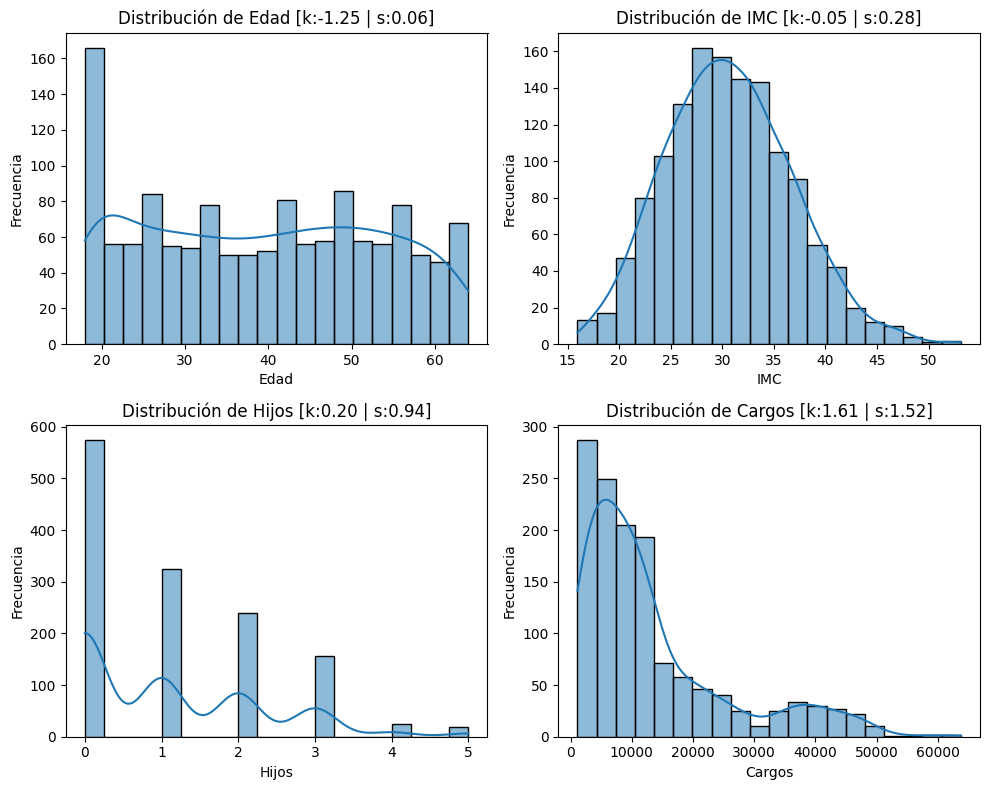

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

print_bold("Histogramas de Variables Numéricas")

# Crear una figura con 2 filas y 2 columnas para los histogramas
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
axes = axes.flatten() # Aplanar el array de axes para facilitar la iteración

# Variables numéricas a graficar
num_vars = ['age', 'bmi', 'children', 'charges']

# Generar histogramas para cada variable numérica
for i, var in enumerate(num_vars):
  var_name = translated_names[var]
  kurt_value = df[var].kurt()
  skew_value = df[var].skew()
  sns.histplot(df[var], kde=True, ax=axes[i], bins=20)
  axes[i].set_title(f'Distribución de {var_name} [k:{kurt_value:.2f} | s:{skew_value:.2f}]')
  axes[i].set_xlabel(var_name)
  axes[i].set_ylabel('Frecuencia')

plt.tight_layout() # Ajustar el diseño para evitar superposiciones
plt.show()

##Nota: Análisis de histogramas
A continuación se muestran la interpretación visual, parte de las medidas de tendencia central se abordaron en la descripción estadística y aqui se abunda en la curtosis y sesgo.
**Edad:** Encontramos una distribucion de frecuencias principalmente uniforme a lo largo de los intervalos de edades con una notoria diferencia en el primer intervalo, cuya frecuencia se dispara a casi tres veces la frecuencia de los otros intervalos.

**IMC:** Este es el dato mas acercado en su comportamiento a una distribución normal, centrado en 30, con un rango de 16 a 53 y sin valores atípicos en ninguno de sus extremos.

**Hijos:** El gráfico muestra una distribución descendente hacia la derecha con una alta concentración de datos a la izquierda.

**Cargos:** Aligual que la variable anterior los datos se encuentran concentrados a la izquierda con un sesgo a la derecha y una moda secundaria alrededor de los 40 mil.

El análisis de sesgo y curtosis se proporciona en la siguiente tabla.
En el caso de la curtosis, la platicúrtica denota una curva de distribucion aplanada; la mesocurtica se acerca mucho a una distribución normal y la leptocúrtica presenta mas concentracion de datos al centro con colas pesadas.
|Variable|Sesgo|Curtosis|
|---|---|---|
|Edad|Sin sesgo relevante|Platicúrtica|
|IMC|Sin sesgo relevante|Mesocurtica|
|Hijos|Sesgo moderado con cola derecha|Mesocurtica|
|Cargos|Sesgo relevante con cola derecha|Leptocúrtica|


Boxplots de Variables Numéricas


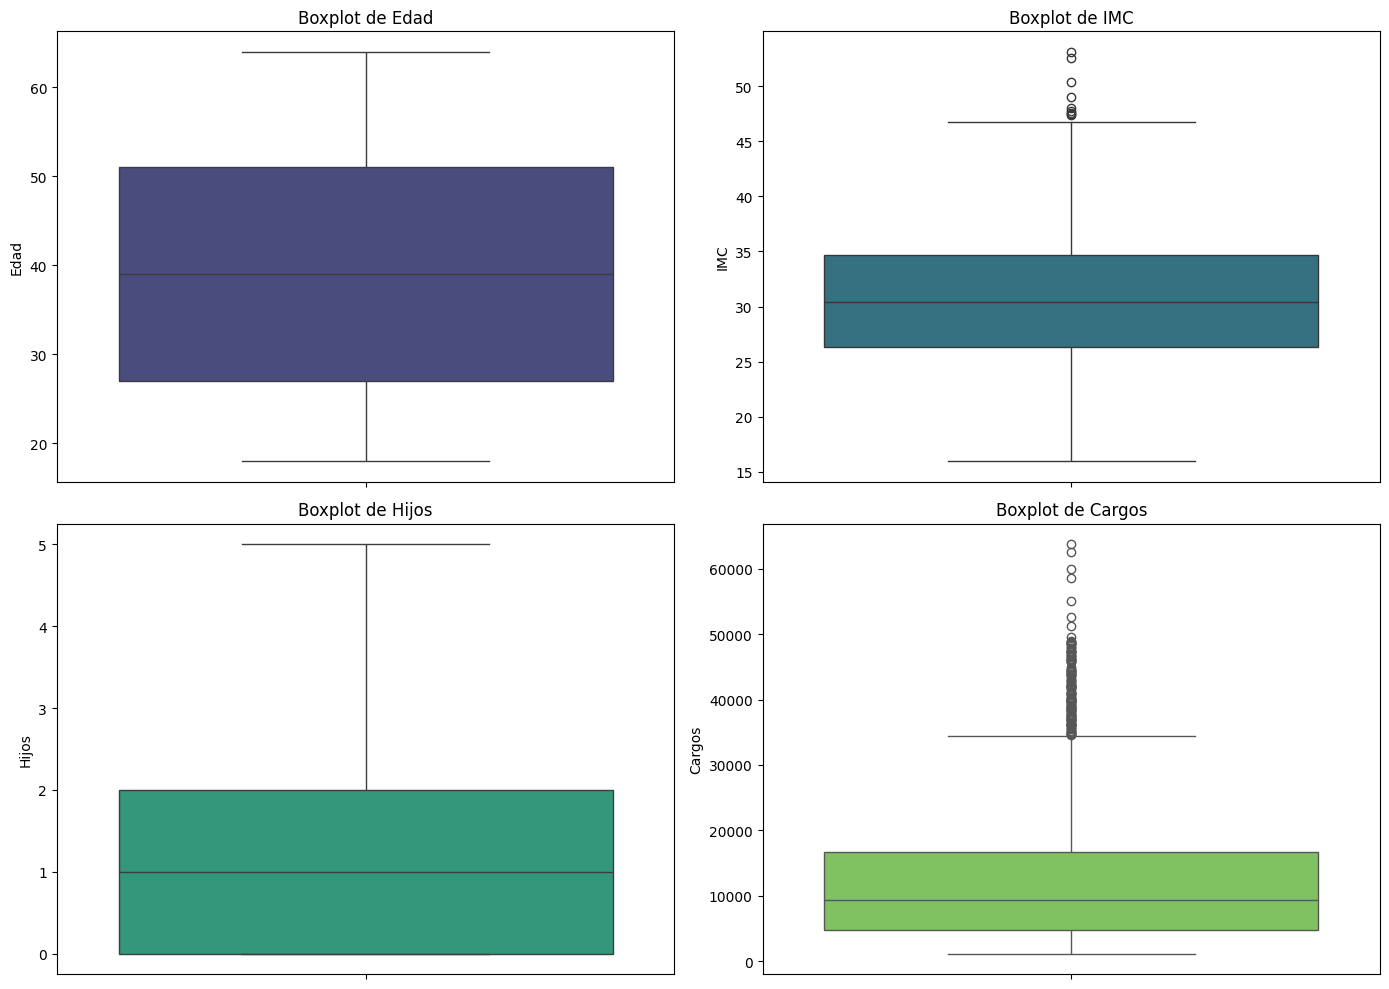

In [93]:
print_bold("Boxplots de Variables Numéricas")

# Crear una figura con 2 filas y 2 columnas para los boxplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten() # Aplanar el array de axes para facilitar la iteración

# Variables numéricas a graficar
num_vars = ['age', 'bmi', 'children', 'charges']

# Obtener una lista de colores de la paleta 'viridis'
colors = sns.color_palette('viridis', len(num_vars))

# Generar boxplots para cada variable numérica
for i, var in enumerate(num_vars):
  var_name = translated_names[var]
  sns.boxplot(y=df[var], ax=axes[i], color=colors[i]) # Usar 'color' en lugar de 'palette'
  axes[i].set_title(f'Boxplot de {var_name}')
  axes[i].set_ylabel(var_name)

plt.tight_layout() # Ajustar el diseño para evitar superposiciones
plt.show()

##Nota:Análisis de boxplots
**Edad:** La edad presenta una mediana de 39 años y la carga central de datos delimitada por los 27 y 51 años, va de los 18 a los 64 años sin valores atípicos.

**IMC:**Con un rango muy largo que va de los 16 a los 53 aproximadamente, presenta una alta concentracion entre los 26 y los 35 con valores atípicos en los valores superiores

**Hijos:**La mayoría de la población reporta tener a lo mas dos hijos con un rango de valores que va de cero a 5 hijos. La mediana denota que por lo menos la mitad tiene a lo mucho 1 hijo.

**Cargos:** Tiene una alta concentracion de casos entre 4740 y 16640, por lo que muestra un sesgo alto a la derecha, contando incluso con valores atípicos en ese sentido. Su rango va de 1121 a 63770.

Nótese que los valores proporcionados se basan en la descripción estadística del dataframe.

In [94]:
print(df['sex'].value_counts())
print(df['smoker'].value_counts())
print(df['region'].value_counts())

sex
male      676
female    662
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64



Gráficos de Barras para Variables Categóricas


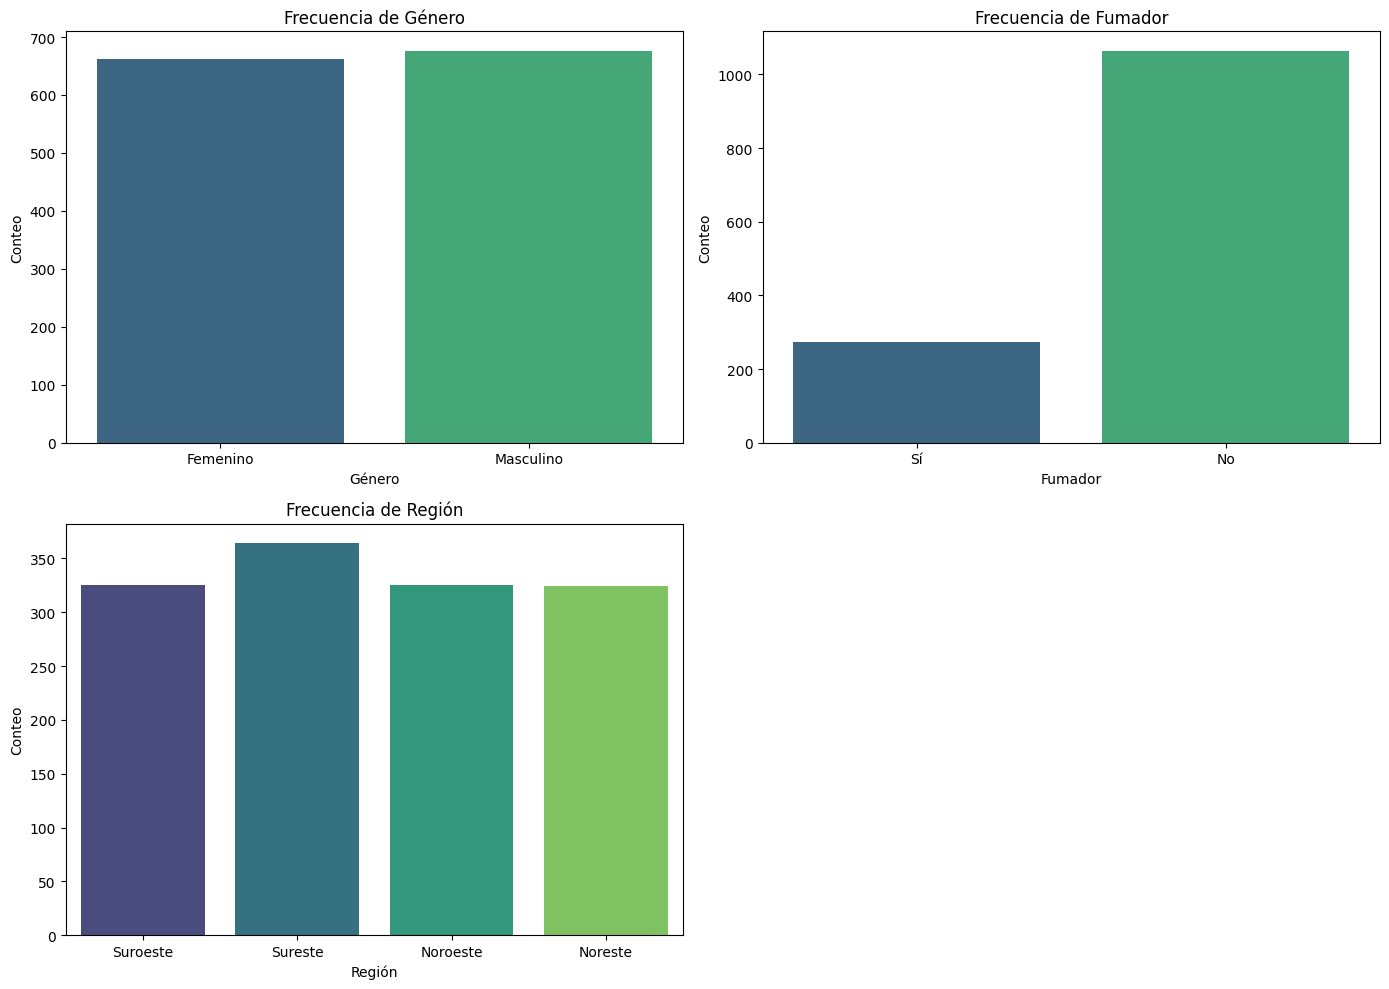

In [95]:
print_bold("Gráficos de Barras para Variables Categóricas")

# Variables categóricas a graficar
cat_vars = ['sex', 'smoker', 'region']

# Determinar el número de filas y columnas para la subgráfica
n_rows = (len(cat_vars) + 1) // 2 # 2 columnas por fila
fig, axes = plt.subplots(nrows=n_rows, ncols=2, figsize=(14, 5 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] # Asegurarse de que axes sea iterable

# Generar gráficos de barras para cada variable categórica
for i, var in enumerate(cat_vars):
  var_name = translated_names[var]

  # Plot the countplot with the original column values
  sns.countplot(x=df[var], ax=axes[i], palette='viridis', hue=df[var], legend=False)

  # Get current tick locations and labels
  tick_locations = axes[i].get_xticks()
  current_labels = [t.get_text() for t in axes[i].get_xticklabels()]
  translated_tick_labels = [translated_names.get(label, label) for label in current_labels]

  # Set ticks explicitly before setting labels to avoid the warning
  axes[i].set_xticks(tick_locations)
  axes[i].set_xticklabels(translated_tick_labels)

  axes[i].set_title(f'Frecuencia de {var_name}')
  axes[i].set_xlabel(var_name)
  axes[i].set_ylabel('Conteo')

# Ocultar ejes vacíos si hay alguno
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##Nota: Análisis de Gráficas de Barras
Se observa en esta serie de gráficas de barras la frecuencia de los distintos valores para las variables categóricas; los valores precisos vienen de la celda previa que usa df.value_counts() para obtenerlos.

**Género:** Es una caategoría con un balance casi perfecto presentando una frecuencia de 676 para `masculino` y 662 para `femenino`

**Fumador:** Tan solo un poco mas del 20% de la población reporta ser `fumador` con 274 casos de 1338 registrados.

**Región:** La frecuencia de la región registrada para esta población esta casi balanceada con valores de 325 para `suroeste` y `noroeste`, 324 para `noreste` y tan solo un ligero incremento para `sureste` con 364 apariciones.

## **🔹 Paso 3: Matriz de Correlación**
✅ Calcular la matriz de correlación **solo para variables numéricas**.

✅ Generar un **mapa de calor** para visualizar relaciones.

📌 **Pregunta:** ¿Qué variables están más correlacionadas con el target (`charges`)?

---



In [96]:
print_bold("Matriz de Correlación (Variables Numéricas)")

# Seleccionar solo las variables numéricas para la correlación
# num_vars ya está definido en celdas anteriores: ['age', 'bmi', 'children', 'charges']
correlation_matrix = df[num_vars].corr()

# Translate the column and index names of the correlation matrix
correlation_matrix.columns = [translated_names.get(col, col) for col in correlation_matrix.columns]
correlation_matrix.index = [translated_names.get(idx, idx) for idx in correlation_matrix.index]

correlation_matrix


Matriz de Correlación (Variables Numéricas)


,Edad,IMC,Hijos,Cargos
Edad,1.00000,0.10927,0.04247,0.29901
IMC,0.10927,1.00000,0.01276,0.19834
Hijos,0.04247,0.01276,1.00000,0.06800
Cargos,0.29901,0.19834,0.06800,1.00000


##Nota: Matriz de Correlación
La matriz de correlación genera valores en el rango de -1 a 1, que denotan la correlación entre las variables incluidas en el cálculo. Asi, valores positivos denotan una relación directamente proporcional conforme se acercan a 1 e inversamente proporcional dependiendo de que tan cercano a -1 se encuentre el valor de correlación.
El efecto es mas fácilmente visible con el mapa de calor que se muestra a continuación.

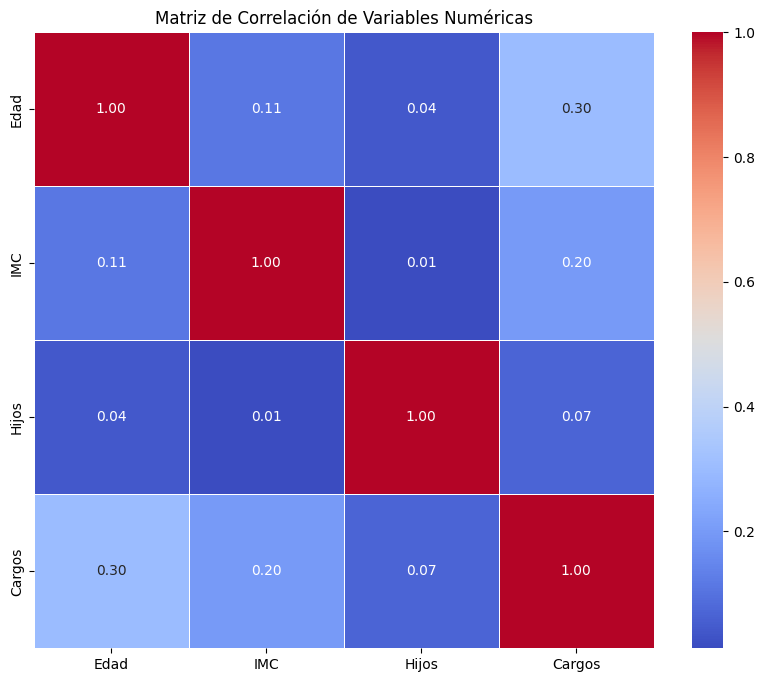

In [97]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()


##Nota: Mapa de Calor
El mapa de calor nos facilita la visualización de las correlaciones entre distintas variables y en el presente gráfico podemos observar que no hay relaciones importantes y solo algunas existen pero son muy débiles.

In [98]:

print_bold("Variables más correlacionadas con 'Cargos':")
# Need to use the translated 'Cargos' for sorting if it exists
charges_correlation_key = translated_names.get('charges', 'charges')
if charges_correlation_key in correlation_matrix.columns:
    charges_correlation = correlation_matrix[charges_correlation_key].sort_values(ascending=False)
else:
    # Fallback if 'charges' or its translation is not found (shouldn't happen with current logic)
    charges_correlation = correlation_matrix['charges'].sort_values(ascending=False)
display(charges_correlation)


Variables más correlacionadas con 'Cargos':


,Cargos
Cargos,1.00000
Edad,0.29901
IMC,0.19834
Hijos,0.06800


##Nota: Correlación de Variables con Respecto a Cargos
En esta lista podemos observar la correlación de las otras variables involucradas con respecto a la variable dependiente u objetivo `Cargos`.
La correlación muestra una relación positiva moderada de `Cargos` con respecto a `Edad` y muy débil en el caso de  `IMC`, y por su lado `Hijos` no aporta nada al comportamiento de `Cargos`.



#### **🔹 Paso 4: Preprocesamiento**  
🔧 **Tareas:**  
1. Manejar valores faltantes con `SimpleImputer`.  
2. Codificar variables categóricas con `OneHotEncoder`.  
3. Estandarizar variables numéricas con `StandardScaler`.  
✅ Verificar que el dataset transformado no tenga valores nulos.  

In [99]:
print_bold("Ocurrencias de Valores Faltantes")
print(df.isna().sum())
if df.isnull().values.any():
  print_bold("El conjunto de datos contiene valores nulos.")
else:
  print_bold("El conjunto de datos no contiene valores nulos.")


Ocurrencias de Valores Faltantes
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

El conjunto de datos no contiene valores nulos.


### **Paso 4.1: Simulación y Demostración de Imputación de Valores Faltantes**

Tomando como premisa que el Dataframe original no cuenta con valores nulos ni faltantes, como se demostró en la celda previa. Para demostrar el funcionamiento de `SimpleImputer`, crearemos una copia del DataFrame original (`df_simulacion_nulos`) e introduciremos artificialmente algunos valores `NaN` en posiciones específicas. Luego, aplicaremos los imputadores y compararemos la región del DataFrame antes y después de la imputación.

In [100]:
import numpy as np
from sklearn.impute import SimpleImputer

print_bold("Simulación de Valores Faltantes y su Imputación")

# Crear una copia del DataFrame original para la simulación
df_simulacion_nulos = df.copy()

# Introducir valores nulos artificialmente en las posiciones elegidas:
# (fila 3, columna 3 -> 'children')
# (fila 4, columna 4 -> 'smoker')
# (fila 5, columna 5 -> 'region')

df_simulacion_nulos.iloc[3, 3] = np.nan # children (numérica)
df_simulacion_nulos.iloc[4, 4] = np.nan # smoker (categórica)
df_simulacion_nulos.iloc[5, 5] = np.nan # region (categórica)

print_bold("DataFrame con valores nulos simulados (región afectada):")
display(df_simulacion_nulos.loc[2:6, ['children', 'smoker', 'region']])

# Re-aplicar SimpleImputer a este DataFrame con nulos simulados

# Columnas numéricas y categóricas para la imputación (como en el paso anterior)
num_cols_to_impute = ['age', 'bmi', 'children']
cat_cols_to_impute = ['sex', 'smoker', 'region']

# Imputador para columnas numéricas (media)
imputer_numeric_sim = SimpleImputer(strategy='mean')
df_simulacion_nulos[num_cols_to_impute] = imputer_numeric_sim.fit_transform(df_simulacion_nulos[num_cols_to_impute])

# Imputador para columnas categóricas (moda)
imputer_categorical_sim = SimpleImputer(strategy='most_frequent')
df_simulacion_nulos[cat_cols_to_impute] = imputer_categorical_sim.fit_transform(df_simulacion_nulos[cat_cols_to_impute])

print_bold("DataFrame después de la imputación (misma región):")
display(df_simulacion_nulos.loc[2:6, ['children', 'smoker', 'region']])

print_bold("Verificación de nulos después de la simulación e imputación:")
print(df_simulacion_nulos.isna().sum().sum())


Simulación de Valores Faltantes y su Imputación

DataFrame con valores nulos simulados (región afectada):


,children,smoker,region
2,3.00000,no,southeast
3,NaN,no,northwest
4,0.00000,NaN,northwest
5,0.00000,no,NaN
6,1.00000,no,southeast



DataFrame después de la imputación (misma región):


,children,smoker,region
2,3.00000,no,southeast
3,1.09574,no,northwest
4,0.00000,no,northwest
5,0.00000,no,southeast
6,1.00000,no,southeast



Verificación de nulos después de la simulación e imputación:
0


Nota: Imputación de Valores Faltantes
Se ha demostrado el uso de SimpleImputer para imputar valores faltantes de forma controlada en una copia del Dataframe original.
Se introdujeron datos nulos en celdas cercanas del Dataframe y se reporta el contenido de las mismas antes y después de la imputación exitosa utilizando el valor medio de cada columna.

### Paso 4.2: Codificar variables categóricas con `OneHotEncoder`.

In [101]:
from sklearn.preprocessing import OneHotEncoder

print_bold('Codificación One-Hot de Variables Categóricas')

# Crear una copia del DataFrame original para realizar las transformaciones
preprocessed_df = df.copy()

# Identificar las variables categóricas (excluyendo 'charges' que es la target)
cat_vars_to_encode = ['sex', 'smoker', 'region']

# Crear una instancia de OneHotEncoder
# handle_unknown='ignore' para manejar categorías no vistas durante el entrenamiento
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')

# Ajustar y transformar las variables categóricas de la copia
df_encoded_data = ohe.fit_transform(preprocessed_df[cat_vars_to_encode])

# Crear un DataFrame con las columnas codificadas
# ohe.get_feature_names_out() genera los nombres de las nuevas columnas (ej: 'sex_male', 'smoker_yes')
df_encoded = pd.DataFrame(df_encoded_data, columns=ohe.get_feature_names_out(cat_vars_to_encode), index=preprocessed_df.index)

# Eliminar las columnas categóricas originales de la copia
preprocessed_df = preprocessed_df.drop(columns=cat_vars_to_encode)

# Concatenar las columnas codificadas al DataFrame preprocessed_df
preprocessed_df = pd.concat([preprocessed_df, df_encoded], axis=1)

print_bold('Primeras filas del DataFrame preprocessed_df después de la codificación One-Hot:')
display(preprocessed_df.head())

print_bold('Estructura del DataFrame preprocessed_df después de la codificación One-Hot:')
display(preprocessed_df.info())



Codificación One-Hot de Variables Categóricas

Primeras filas del DataFrame preprocessed_df después de la codificación One-Hot:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.90000,0,16884.92400,0.00000,1.00000,0.00000,0.00000,1.00000
1,18,33.77000,1,1725.55230,1.00000,0.00000,0.00000,1.00000,0.00000
2,28,33.00000,3,4449.46200,1.00000,0.00000,0.00000,1.00000,0.00000
3,33,22.70500,0,21984.47061,1.00000,0.00000,1.00000,0.00000,0.00000
4,32,28.88000,0,3866.85520,1.00000,0.00000,1.00000,0.00000,0.00000



Estructura del DataFrame preprocessed_df después de la codificación One-Hot:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   bmi               1338 non-null   float64
 2   children          1338 non-null   int64  
 3   charges           1338 non-null   float64
 4   sex_male          1338 non-null   float64
 5   smoker_yes        1338 non-null   float64
 6   region_northwest  1338 non-null   float64
 7   region_southeast  1338 non-null   float64
 8   region_southwest  1338 non-null   float64
dtypes: float64(7), int64(2)
memory usage: 94.2 KB


None

## Nota: Codificación One-Hot
Las variables categóricas 'sex', 'smoker' y 'region' han sido transformadas utilizando OneHotEncoder. Esto crea nuevas columnas binarias para cada categoría única en las variables originales. Por ejemplo, 'sex' se ha dividido en 'sex_female' y 'sex_male', donde un 1 indica la presencia de esa categoría y un 0 su ausencia. Las columnas categóricas originales han sido eliminadas y reemplazadas por estas nuevas columnas codificadas.
Estas nuevas columnas "dummy" han sido mencionadas como binarias por su característica dicotómica de acuerdo a algunas fuentes. (Gareth et al., p.171, 2023), (Hastis et al., p.13, 2017)
Despues del análisis VIF (Variance Inflation Factor) se descubrió la necesidad de eliminar una variable `dummy` de cada variable codificada con `one_hot_encoder`, por lo que se reduce el número de columnas del dataframe preprocesado.

### Paso 4.3: Estandarizar variables numéricas con `StandardScaler`.

In [116]:
import pandas as pd # Import pandas if not already imported in this cell
from sklearn.preprocessing import StandardScaler

# Establecer la precisión de visualización de pandas a 4 decimales
pd.set_option('display.float_format', '{:.5f}'.format)

print_bold('Estandarización de Variables Numéricas')

# Identificar las variables numéricas para estandarizar
# Excluir 'charges' (la variable objetivo) ya que no se estandariza junto con las variables independientes.
# También excluimos las variables dummy creadas por OneHotEncoder, que ya son 0 o 1.
num_vars_to_scale = ['age', 'bmi', 'children']

# Crear una instancia de StandardScaler
scaler = StandardScaler()

# Ajustar y transformar las variables numéricas en el DataFrame preprocessed_df
preprocessed_df[num_vars_to_scale] = scaler.fit_transform(preprocessed_df[num_vars_to_scale])

print_bold('Primeras filas del DataFrame preprocessed_df después de la estandarización:')
display(preprocessed_df.head())

print_bold('Estadísticas descriptivas de las variables numéricas estandarizadas:')
display(preprocessed_df[num_vars_to_scale].describe())


Estandarización de Variables Numéricas

Primeras filas del DataFrame preprocessed_df después de la estandarización:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-1.43876,-0.45332,-0.90861,16884.92400,0.00000,1.00000,0.00000,0.00000,1.00000
1,-1.50997,0.50962,-0.07877,1725.55230,1.00000,0.00000,0.00000,1.00000,0.00000
2,-0.79795,0.38331,1.58093,4449.46200,1.00000,0.00000,0.00000,1.00000,0.00000
3,-0.44195,-1.30553,-0.90861,21984.47061,1.00000,0.00000,1.00000,0.00000,0.00000
4,-0.51315,-0.29256,-0.90861,3866.85520,1.00000,0.00000,1.00000,0.00000,0.00000



Estadísticas descriptivas de las variables numéricas estandarizadas:


,age,bmi,children
count,1338.00000,1338.00000,1338.00000
mean,0.00000,0.00000,0.00000
std,1.00037,1.00037,1.00037
min,-1.50997,-2.41201,-0.90861
25%,-0.86915,-0.71641,-0.90861
50%,-0.01474,-0.04321,-0.07877
75%,0.83967,0.66116,0.75108
max,1.76529,3.68552,3.24062


## Nota: Estandarización de Variables Numéricas
Las variables numéricas 'age', 'bmi' y 'children' han sido estandarizadas utilizando `StandardScaler`. Este proceso transforma los datos para que tengan una media de 0 y una desviación estándar de 1. La estandarización es crucial para algoritmos que son sensibles a la escala de las características (como regresión Ridge y Lasso), ya que asegura que todas las características contribuyan equitativamente al modelo, evitando que aquellas con rangos de valores más grandes dominen el proceso de aprendizaje.

#### **🔹 Paso 5: Modelado (Lasso y Ridge)**  
🎯 **Para cada modelo:**  
1. Ajustar el modelo con los hiperparámetros dados (`alpha=0.1` para Lasso, `alpha=1.0` para Ridge).  
2. Calcular **MSE** y **R²** para evaluar rendimiento.  
3. Analizar los coeficientes para identificar variables importantes.  

📌 **Pregunta:**  
- ¿Qué modelo tiene un mejor R²? ¿Por qué crees que ocurre esto?  
- ¿Qué variables tienen coeficientes cercanos a cero en Lasso? ¿Por qué?

### **Paso 5.1: Modelado con Regresión Lasso**

In [117]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

print_bold("Preparando los datos para el modelado")

# Separar las características (X) y la variable objetivo (y)
X = preprocessed_df.drop('charges', axis=1)
y = preprocessed_df['charges']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")


Preparando los datos para el modelado
Dimensiones de X_train: (936, 8)
Dimensiones de X_test: (402, 8)
Dimensiones de y_train: (936,)
Dimensiones de y_test: (402,)


## Nota: División de Datos
Antes de entrenar cualquier modelo, es crucial dividir el conjunto de datos en un conjunto de entrenamiento y un conjunto de prueba. Esto nos permite evaluar el rendimiento del modelo en datos no vistos, lo que proporciona una estimación más realista de cómo se desempeñará en escenarios del mundo real y ayuda a detectar el sobreajuste. Aquí, hemos utilizado una división del 70% para entrenamiento y 30% para prueba.

In [118]:
print_bold("Entrenamiento y Evaluación del Modelo Lasso")

# 1. Ajustar el modelo Lasso
# El hiperparámetro alpha controla la fuerza de la regularización L1.
# Un alpha más alto aumenta la penalización y reduce más coeficientes a cero.
lasso_model1 = Lasso(alpha=0.1, random_state=42)
lasso_model2 = Lasso(alpha=1, random_state=42)
lasso_model3 = Lasso(alpha=50, random_state=42) # Nuevo modelo con alpha=100

lasso_model1.fit(X_train, y_train)
lasso_model2.fit(X_train, y_train)
lasso_model3.fit(X_train, y_train)

# 2. Realizar predicciones en el conjunto de prueba
y_pred_lasso1 = lasso_model1.predict(X_test)
y_pred_lasso2 = lasso_model2.predict(X_test)
y_pred_lasso3 = lasso_model3.predict(X_test) # Predicciones para el nuevo modelo

# Calcular y mostrar el MSE y R²
mse_lasso1 = mean_squared_error(y_test, y_pred_lasso1)
mse_lasso2 = mean_squared_error(y_test, y_pred_lasso2)
mse_lasso3 = mean_squared_error(y_test, y_pred_lasso3) # MSE para el nuevo modelo

r2_lasso1 = r2_score(y_test, y_pred_lasso1)
r2_lasso2 = r2_score(y_test, y_pred_lasso2)
r2_lasso3 = r2_score(y_test, y_pred_lasso3) # R² para el nuevo modelo

print(f"Error Cuadrático Medio (MSE) para Lasso(0.1)=[{mse_lasso1:.4f}] Lasso(1)=[{mse_lasso2:.4f}] Lasso(50)=[{mse_lasso3:.4f}]")
print(f"Coeficiente de Determinación (R²) para Lasso(0.1)=[{r2_lasso1:.4f}] Lasso(1)=[{r2_lasso2:.4f}] Lasso(50)=[{r2_lasso3:.4f}] ")


Entrenamiento y Evaluación del Modelo Lasso
Error Cuadrático Medio (MSE) para Lasso(0.1)=[33780408.0527] Lasso(1)=[33779559.8336] Lasso(50)=[33888897.2002]
Coeficiente de Determinación (R²) para Lasso(0.1)=[0.7696] Lasso(1)=[0.7696] Lasso(50)=[0.7689] 


## Nota: Rendimiento del Modelo Lasso
Se han entrenado tres modelos Lasso con valores de `alpha` de 0.1, 1.0 y 50. El **Error Cuadrático Medio (MSE)** mide el promedio de los errores al cuadrado entre los valores predichos y los reales; un MSE más bajo indica un mejor ajuste. El **Coeficiente de Determinación (R²)** indica la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes. Un R² más cercano a 1 indica que el modelo explica una mayor proporción de la varianza en la variable objetivo.

Observamos que para `alpha=0.1` y `alpha=1.0`, ambos modelos presentan un rendimiento muy similar en términos de MSE y R². La penalización L1 con estos valores de `alpha` es relativamente baja, por lo que el modelo resultante es muy parecido al de una regresión lineal sin regularización.

Sin embargo, al incrementar `alpha` a 50, la regularización es mucho más fuerte. Esto se traduce en un ligero aumento del MSE y una ligera disminución del R², lo que sugiere que una penalización excesivamente alta está empezando a comprometer la capacidad del modelo para ajustarse bien a los datos, aunque podría estar seleccionando un subconjunto más pequeño de características.

In [119]:
print_bold("Análisis de Coeficientes de los Modelos Lasso")

# Crear un DataFrame para visualizar los coeficientes de los tres modelos
lasso_coefficients = pd.DataFrame({
    'Característica': X.columns,
    'Lasso1 (alpha=0.1)': lasso_model1.coef_,
    'Lasso2 (alpha=1.0)': lasso_model2.coef_,
    'Lasso3 (alpha=100)': lasso_model3.coef_
})

# Ordenar los coeficientes por el valor del tercer modelo (alpha=100) para ver las más importantes y su dirección
lasso_coefficients = lasso_coefficients.sort_values(by='Lasso3 (alpha=100)', ascending=False)

display(lasso_coefficients)


Análisis de Coeficientes de los Modelos Lasso


,Característica,Lasso1 (alpha=0.1),Lasso2 (alpha=1.0),Lasso3 (alpha=100)
4,smoker_yes,23627.78879,23622.57866,23327.27308
0,age,3669.74894,3668.93365,3626.23521
1,bmi,2126.68461,2124.72075,2019.15465
2,children,511.00662,510.33329,474.00357
3,sex_male,104.46295,101.32293,0.00000
5,region_northwest,-485.32949,-471.02433,-0.00000
7,region_southwest,-924.67339,-909.91281,-254.13903
6,region_southeast,-969.26375,-954.03201,-272.29937


## Nota: Coeficientes de Lasso
Los coeficientes del modelo Lasso nos indican la importancia de cada característica para predecir la variable objetivo (`charges`). Debido a la regularización L1, Lasso tiene la capacidad de reducir los coeficientes de las características menos importantes exactamente a cero, realizando así una selección de características inherente. Las características con coeficientes más grandes (en valor absoluto) son consideradas más influyentes en las predicciones del modelo.

En este análisis, hemos comparado los coeficientes de tres modelos Lasso con diferentes valores de `alpha` (0.1, 1.0 y 50). Observamos cómo, a medida que `alpha` aumenta (especialmente en `Lasso3` con `alpha=50`), la magnitud de algunos coeficientes disminuye e incluso algunos pueden ser reducidos a cero. Esto demuestra el efecto de la regularización L1 en la simplificación del modelo y la selección de características.

### **Paso 5.2: Modelado con Regresión Ridge**

In [120]:
from sklearn.linear_model import Ridge

print_bold("Entrenamiento y Evaluación de los Modelos Ridge")

# 1. Ajustar los modelos Ridge con diferentes valores de alpha
ridge_model1 = Ridge(alpha=0.1, random_state=42)
ridge_model2 = Ridge(alpha=1.0, random_state=42)
ridge_model3 = Ridge(alpha=50, random_state=42)

ridge_model1.fit(X_train, y_train)
ridge_model2.fit(X_train, y_train)
ridge_model3.fit(X_train, y_train)

# 2. Realizar predicciones en el conjunto de prueba
y_pred_ridge1 = ridge_model1.predict(X_test)
y_pred_ridge2 = ridge_model2.predict(X_test)
y_pred_ridge3 = ridge_model3.predict(X_test)

# Calcular y mostrar el MSE y R²
mse_ridge1 = mean_squared_error(y_test, y_pred_ridge1)
mse_ridge2 = mean_squared_error(y_test, y_pred_ridge2)
mse_ridge3 = mean_squared_error(y_test, y_pred_ridge3)

r2_ridge1 = r2_score(y_test, y_pred_ridge1)
r2_ridge2 = r2_score(y_test, y_pred_ridge2)
r2_ridge3 = r2_score(y_test, y_pred_ridge3)

print(f"Error Cuadrático Medio (MSE) para Ridge(0.1)=[{mse_ridge1:.4f}] Ridge(1.0)=[{mse_ridge2:.4f}] Ridge(50)=[{mse_ridge3:.4f}]")
print(f"Coeficiente de Determinación (R²) para Ridge(0.1)=[{r2_ridge1:.4f}] Ridge(1.0)=[{r2_ridge2:.4f}] Ridge(50)=[{r2_ridge3:.4f}] ")


Entrenamiento y Evaluación de los Modelos Ridge
Error Cuadrático Medio (MSE) para Ridge(0.1)=[33783726.7635] Ridge(1.0)=[33815845.0564] Ridge(50)=[40352492.5731]
Coeficiente de Determinación (R²) para Ridge(0.1)=[0.7696] Ridge(1.0)=[0.7694] Ridge(50)=[0.7248] 


In [121]:
print_bold("Análisis de Coeficientes de los Modelos Ridge")

# Crear un DataFrame para visualizar los coeficientes de los tres modelos Ridge
ridge_coefficients = pd.DataFrame({
    'Característica': X.columns,
    'Ridge1 (alpha=0.1)': ridge_model1.coef_,
    'Ridge2 (alpha=1.0)': ridge_model2.coef_,
    'Ridge3 (alpha=50)': ridge_model3.coef_
})

# Ordenar los coeficientes por el valor del tercer modelo (alpha=50) para ver las más importantes y su dirección
ridge_coefficients = ridge_coefficients.sort_values(by='Ridge3 (alpha=50)', ascending=False)

display(ridge_coefficients)


Análisis de Coeficientes de los Modelos Ridge


,Característica,Ridge1 (alpha=0.1),Ridge2 (alpha=1.0),Ridge3 (alpha=50)
4,smoker_yes,23612.91945,23474.79327,17804.66344
0,age,3669.19961,3663.46333,3395.92157
1,bmi,2126.51897,2123.07671,1979.23794
2,children,511.22550,512.50939,557.37772
3,sex_male,105.40336,110.66406,280.23798
5,region_northwest,-486.20804,-479.81411,-323.05362
6,region_southeast,-969.02147,-951.74935,-407.89317
7,region_southwest,-925.01480,-913.43611,-565.90753


## Nota: Coeficientes de Ridge
Los coeficientes del modelo Ridge nos indican la importancia de cada característica para predecir la variable objetivo (`charges`), de manera similar a Lasso. Sin embargo, a diferencia de Lasso, la regularización L2 utilizada por Ridge penaliza la suma de los cuadrados de los coeficientes, lo que tiende a reducirlos hacia cero, pero rara vez los convierte exactamente en cero. Esto significa que Ridge mantiene todas las características en el modelo, pero reduce su impacto en la predicción.

En este análisis, comparamos los coeficientes de los tres modelos Ridge con diferentes valores de `alpha` (0.1, 1.0 y 50). Observamos cómo, a medida que `alpha` aumenta, la magnitud de todos los coeficientes disminuye. Esto demuestra el efecto de la regularización L2 en la reducción de la complejidad del modelo y la prevención del sobreajuste, distribuyendo el efecto de la penalización entre todas las características.

## Nota: Rendimiento de los Modelos Ridge
Se han entrenado tres modelos de Regresión Ridge con valores de `alpha` de 0.1, 1.0 y 50. Al igual que con Lasso, evaluamos su rendimiento utilizando el Error Cuadrático Medio (MSE) y el Coeficiente de Determinación (R²). La regularización Ridge (L2) penaliza la suma de los cuadrados de los coeficientes, lo que ayuda a reducir la complejidad del modelo y a prevenir el sobreajuste. A diferencia de Lasso, Ridge tiende a reducir los coeficientes hacia cero, pero rara vez los convierte exactamente en cero, manteniendo así todas las características en el modelo.

Al comparar los resultados de los tres modelos Ridge, podemos observar cómo el aumento del `alpha` afecta el MSE y el R². Un `alpha` más alto impone una mayor penalización, lo que puede mejorar la generalización si el modelo inicial estaba sobreajustado, pero una penalización excesiva puede llevar a un subajuste si los coeficientes importantes se reducen demasiado.

In [122]:
print_bold("Coeficientes de Lasso3 (alpha=50) - Ordenados por valor del coeficiente")
# Extraer y ordenar los coeficientes de Lasso3
lasso_coefs_sorted = lasso_coefficients[['Característica', 'Lasso3 (alpha=100)']].sort_values(by='Lasso3 (alpha=100)', ascending=False).reset_index(drop=True)
display(lasso_coefs_sorted)

print_bold("Coeficientes de Ridge3 (alpha=50) - Ordenados por valor del coeficiente")
# Extraer y ordenar los coeficientes de Ridge3
ridge_coefs_sorted = ridge_coefficients[['Característica', 'Ridge3 (alpha=50)']].sort_values(by='Ridge3 (alpha=50)', ascending=False).reset_index(drop=True)
display(ridge_coefs_sorted)


Coeficientes de Lasso3 (alpha=50) - Ordenados por valor del coeficiente


,Característica,Lasso3 (alpha=100)
0,smoker_yes,23327.27308
1,age,3626.23521
2,bmi,2019.15465
3,children,474.00357
4,sex_male,0.00000
5,region_northwest,-0.00000
6,region_southwest,-254.13903
7,region_southeast,-272.29937



Coeficientes de Ridge3 (alpha=50) - Ordenados por valor del coeficiente


,Característica,Ridge3 (alpha=50)
0,smoker_yes,17804.66344
1,age,3395.92157
2,bmi,1979.23794
3,children,557.37772
4,sex_male,280.23798
5,region_northwest,-323.05362
6,region_southeast,-407.89317
7,region_southwest,-565.90753


## Nota: Comparación de Coeficientes entre Lasso y Ridge (alpha altos)

Al comparar los coeficientes de los modelos Lasso3 (con `alpha=50`) y Ridge3 (con `alpha=50`), cada uno ordenado por sus propios valores, podemos observar diferencias clave en cómo cada técnica de regularización impacta la selección de características, su magnitud y dirección:

*   **Selección de Características (Lasso):** Como se anticipó, Lasso tiende a reducir los coeficientes de las características menos relevantes exactamente a cero. En la tabla de coeficientes de Lasso, se puede ver cómo algunas características tienen un 'Lasso3 (alpha=100)' de 0.00000, indicando que Lasso las ha excluido efectivamente del modelo. Esto hace que Lasso sea útil para la selección de características y para crear modelos más esparsos y fáciles de interpretar cuando hay muchas características.

*   **Reducción de Magnitud (Ridge):** Ridge, por otro lado, reduce la magnitud de los coeficientes hacia cero, pero rara vez los fuerza a ser exactamente cero. Esto se refleja en que la mayoría de los 'Ridge3 (alpha=50)' son valores pequeños pero distintos de cero, incluso para características que Lasso ha descartado. Ridge mantiene todas las características en el modelo, distribuyendo la penalización entre ellas, lo que puede ser beneficioso cuando todas las características son potencialmente relevantes pero hay multicolinealidad.

*   **Impacto en el Orden y la Dirección de Importancia:** Al observar las tablas separadas, notamos que el orden de las características por importancia, y también la dirección de su impacto (positiva o negativa), difiere entre Lasso y Ridge. Lasso prioriza fuertemente las características más impactantes, llevando otras a cero. Ridge, al no eliminar características por completo, mantiene una influencia de todas ellas, lo que puede alterar el ranking de importancia percibido, especialmente para aquellas con coeficientes pequeños pero no nulos. Los coeficientes positivos indican una relación directa con la variable objetivo, mientras que los negativos indican una relación inversa. Esto resalta que la 'importancia' de una característica y la dirección de su efecto pueden interpretarse de manera diferente según el tipo de regularización aplicada.

*   **Impacto de la Regularización:** Con un `alpha` alto (50 en ambos casos), la regularización es fuerte. En Lasso, esto resulta en una mayor cantidad de coeficientes cero. En Ridge, se observa una reducción sustancial en la magnitud de todos los coeficientes en comparación con modelos Ridge con `alpha` más bajos (como se vio en la tabla de `ridge_coefficients`).

En resumen, esta comparación visual de coeficientes subraya las diferencias fundamentales entre la regularización L1 (Lasso) y L2 (Ridge) en términos de selección de características, la forma en que penalizan los pesos del modelo, y cómo esto afecta la interpretación de la importancia y dirección relativa de cada característica.

#### **🔹 Paso 6: Verificación de Supuestos**  
📉 **Para cada modelo, verificar:**  
1.  **Linealidad** (gráfico de residuos vs predicciones).  
2.  **Normalidad de residuos** (QQ-Plot y test de Shapiro-Wilk).  
3.  **Homocedasticidad** (test de Breusch-Pagan).  
4.  **Multicolinealidad** (VIF > 10 indica problema).  

📌 **Pregunta:**  
- ¿Se cumplen los supuestos en ambos modelos?  
- Si hay heterocedasticidad, ¿cómo podría solucionarse?

### **Paso 6.1: Verificación del Supuesto de Linealidad (Residuos vs. Predicciones)**


Gráfico de Residuos vs. Predicciones para Lasso3


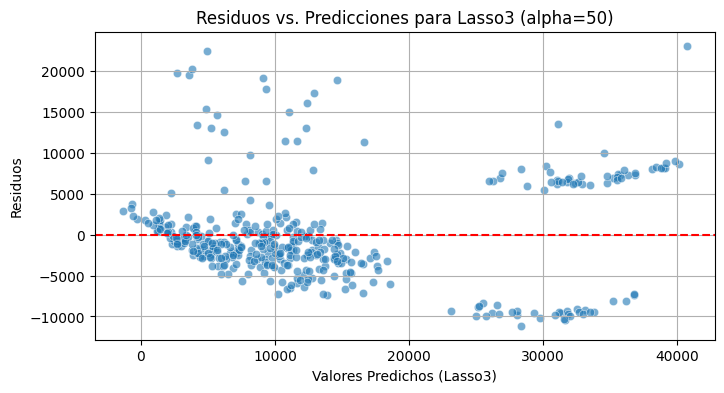


Gráfico de Residuos vs. Predicciones para Ridge3


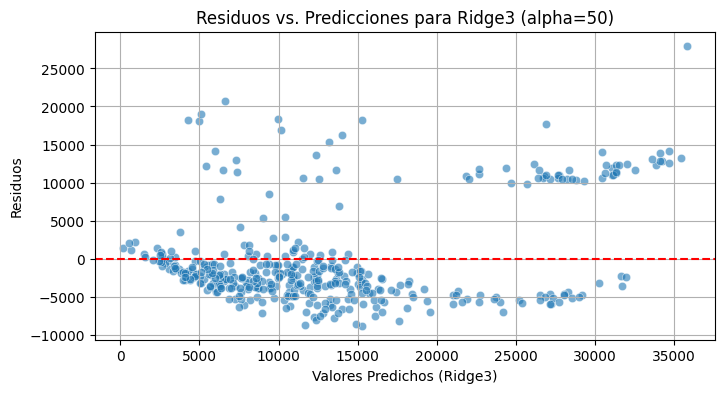

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

print_bold("Gráfico de Residuos vs. Predicciones para Lasso3")
# Calcular residuos para Lasso3
residuals_lasso3 = y_test - y_pred_lasso3

plt.figure(figsize=(8, 4))
sns.scatterplot(x=y_pred_lasso3, y=residuals_lasso3, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuos vs. Predicciones para Lasso3 (alpha=50)')
plt.xlabel('Valores Predichos (Lasso3)')
plt.ylabel('Residuos')
plt.grid(True)
plt.show()

print_bold("Gráfico de Residuos vs. Predicciones para Ridge3")
# Calcular residuos para Ridge3
residuals_ridge3 = y_test - y_pred_ridge3

plt.figure(figsize=(8, 4))
sns.scatterplot(x=y_pred_ridge3, y=residuals_ridge3, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuos vs. Predicciones para Ridge3 (alpha=50)')
plt.xlabel('Valores Predichos (Ridge3)')
plt.ylabel('Residuos')
plt.grid(True)
plt.show()

## Nota: Análisis de Linealidad
Los gráficos de residuos vs. predicciones nos permiten evaluar si los errores del modelo se distribuyen aleatoriamente y si su varianza es constante (homocedasticidad).

**Observaciones para Lasso3 y Ridge3:**

Al analizar ambos gráficos, se observa que los residuos no se distribuyen de manera completamente aleatoria alrededor de la línea horizontal `y=0`. Existe un patrón discernible donde la dispersión de los residuos tiende a aumentar a medida que los valores predichos (`Valores Predichos`) son mayores. Esta forma de 'embudo' es un indicio claro de **heterocedasticidad**, lo que significa que la varianza de los errores no es constante en todo el rango de las predicciones.

Además de la heterocedasticidad, la concentración de puntos y la forma general de la dispersión sugieren que el supuesto de **linealidad** perfecta podría no cumplirse del todo, o que podría haber variables relevantes omitidas o interacciones no lineales que los modelos actuales no están capturando.

### **Paso 6.2: Verificación del Supuesto de Normalidad de Residuos**


QQ-Plot de Residuos para Lasso3


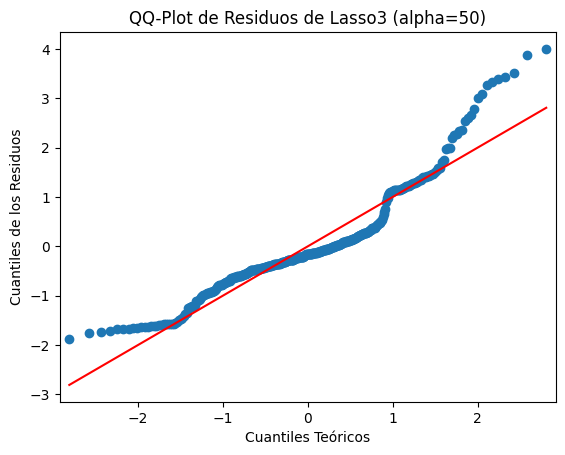


QQ-Plot de Residuos para Ridge3


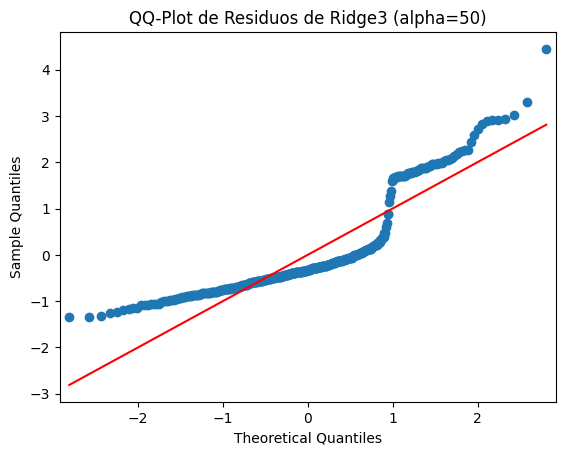

In [129]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

print_bold("QQ-Plot de Residuos para Lasso3")
# Generar QQ-Plot para Lasso3
fig_qq_lasso3 = sm.qqplot(residuals_lasso3, line='s', fit=True)
plt.title('QQ-Plot de Residuos de Lasso3 (alpha=50)')
fig_qq_lasso3.axes[0].set_xlabel('Cuantiles Teóricos')
fig_qq_lasso3.axes[0].set_ylabel('Cuantiles de los Residuos')
plt.show()

print_bold("QQ-Plot de Residuos para Ridge3")
# Generar QQ-Plot para Ridge3
fig_qq_ridge3 = sm.qqplot(residuals_ridge3, line='s', fit=True)
plt.title('QQ-Plot de Residuos de Ridge3 (alpha=50)')
fig_qq_lasso3.axes[0].set_xlabel('Cuantiles Teóricos')
fig_qq_lasso3.axes[0].set_ylabel('Cuantiles de los Residuos')
plt.show()

## Nota: Supuesto de Normalidad
Los QQ-Plots (Quantile-Quantile Plots) se utilizan para visualizar si la distribución de los residuos sigue una distribución normal. Si los puntos se agrupan a lo largo de la línea de 45 grados, esto sugiere que los residuos están distribuidos normalmente.

**Observaciones para Lasso3 y Ridge3:**

En ambos QQ-Plots, se observa que los puntos tienden a desviarse de la línea recta, especialmente en los extremos (colas) de la distribución. Esta desviación es más notable en las colas superiores e inferiores, lo que indica que los residuos no siguen una distribución normal perfecta. Generalmente, los puntos en la parte superior derecha por encima de la línea y los puntos en la parte inferior izquierda por debajo de la línea sugieren que la distribución de los residuos tiene "colas pesadas" (heavy tails) en comparación con una distribución normal.

In [130]:
from scipy import stats

print_bold("Test de Normalidad de Shapiro-Wilk para Lasso3")
shapiro_test_lasso3 = stats.shapiro(residuals_lasso3)
print(f"Estadístico Shapiro-Wilk para Lasso3: {shapiro_test_lasso3.statistic:.4f}")
print(f"P-valor para Lasso3: {shapiro_test_lasso3.pvalue:.4f}")

if shapiro_test_lasso3.pvalue < 0.05:
    print("El p-valor es menor a 0.05, por lo que rechazamos la hipótesis nula de normalidad de residuos para Lasso3.")
else:
    print("El p-valor es mayor a 0.05, por lo que no rechazamos la hipótesis nula de normalidad de residuos para Lasso3.")

print_bold("\nTest de Normalidad de Shapiro-Wilk para Ridge3")
shapiro_test_ridge3 = stats.shapiro(residuals_ridge3)
print(f"Estadístico Shapiro-Wilk para Ridge3: {shapiro_test_ridge3.statistic:.4f}")
print(f"P-valor para Ridge3: {shapiro_test_ridge3.pvalue:.4f}")

if shapiro_test_ridge3.pvalue < 0.05:
    print("El p-valor es menor a 0.05, por lo que rechazamos la hipótesis nula de normalidad de residuos para Ridge3.")
else:
    print("El p-valor es mayor a 0.05, por lo que no rechazamos la hipótesis nula de normalidad de residuos para Ridge3.")


Test de Normalidad de Shapiro-Wilk para Lasso3
Estadístico Shapiro-Wilk para Lasso3: 0.9085
P-valor para Lasso3: 0.0000
El p-valor es menor a 0.05, por lo que rechazamos la hipótesis nula de normalidad de residuos para Lasso3.


Test de Normalidad de Shapiro-Wilk para Ridge3
Estadístico Shapiro-Wilk para Ridge3: 0.7992
P-valor para Ridge3: 0.0000
El p-valor es menor a 0.05, por lo que rechazamos la hipótesis nula de normalidad de residuos para Ridge3.


## Nota: Análisis del Test de Shapiro-Wilk
El Test de Shapiro-Wilk es una prueba estadística que evalúa la hipótesis nula de que una muestra proviene de una población normalmente distribuida. Un p-valor bajo (generalmente menor a 0.05) nos lleva a rechazar esta hipótesis nula, sugiriendo que los residuos no son normales.

**Observaciones para Lasso3 y Ridge3:**

Para ambos modelos (Lasso3 y Ridge3), el p-valor obtenido del test de Shapiro-Wilk es significativamente menor que 0.05 (de hecho, es muy cercano a cero). Esto nos permite rechazar la hipótesis nula de normalidad para los residuos en ambos casos. Este resultado cuantitativo apoya lo observado en los QQ-Plots: los residuos de nuestros modelos no siguen una distribución normal.

**Implicaciones:** La falta de normalidad en los residuos puede afectar la validez de los intervalos de confianza y las pruebas de hipótesis sobre los coeficientes de regresión. Sin embargo, para fines de predicción, la normalidad de los residuos es menos crítica que otros supuestos, especialmente si el tamaño de la muestra es grande.

### **Paso 6.3: Verificación del Supuesto de Homocedasticidad (Test de Breusch-Pagan)**

In [131]:
import statsmodels.api as sm
from statsmodels.stats.api import het_breuschpagan

#=============================================================
print_bold("Test de Breusch-Pagan para Lasso3")
# Para el test de Breusch-Pagan necesitamos los residuos y las variables independientes del modelo.
# Es importante usar los datos de entrenamiento para obtener los predictores originales (X_train) si el modelo fue ajustado con ellos.
# Sin embargo, dado que ya calculamos los residuos sobre el conjunto de prueba, usaremos X_test para la prueba.
# statsmodels requiere un intercepto, así que lo añadimos si no está ya presente en X_test.

X_test_bp = sm.add_constant(X_test, prepend=False)

# Realizar el test de Breusch-Pagan para Lasso3
bp_test_lasso3 = het_breuschpagan(residuals_lasso3, X_test_bp)

labels = ['Estadístico LM', 'P-valor LM', 'Estadístico F', 'P-valor F']
print(dict(zip(labels, bp_test_lasso3)))

if bp_test_lasso3[1] < 0.05:
    print("El p-valor LM es menor a 0.05, por lo que rechazamos la hipótesis nula de homocedasticidad para Lasso3. Hay heterocedasticidad.")
else:
    print("El p-valor LM es mayor a 0.05, por lo que no rechazamos la hipótesis nula de homocedasticidad para Lasso3. Se cumple el supuesto de homocedasticidad.")
#=============================================================
print_bold("\nTest de Breusch-Pagan para Ridge3")
# Realizar el test de Breusch-Pagan para Ridge3
bp_test_ridge3 = het_breuschpagan(residuals_ridge3, X_test_bp)

print(dict(zip(labels, bp_test_ridge3)))

if bp_test_ridge3[1] < 0.05:
    print("El p-valor LM es menor a 0.05, por lo que rechazamos la hipótesis nula de homocedasticidad para Ridge3. Hay heterocedasticidad.")
else:
    print("El p-valor LM es mayor a 0.05, por lo que no rechazamos la hipótesis nula de homocedasticidad para Ridge3. Se cumple el supuesto de homocedasticidad.")


Test de Breusch-Pagan para Lasso3
{'Estadístico LM': np.float64(39.91484934001304), 'P-valor LM': np.float64(3.3228681693049467e-06), 'Estadístico F': np.float64(5.415347661327954), 'P-valor F': np.float64(1.7490055219643499e-06)}
El p-valor LM es menor a 0.05, por lo que rechazamos la hipótesis nula de homocedasticidad para Lasso3. Hay heterocedasticidad.


Test de Breusch-Pagan para Ridge3
{'Estadístico LM': np.float64(98.897600067515), 'P-valor LM': np.float64(7.170982417700792e-18), 'Estadístico F': np.float64(16.028723640587646), 'P-valor F': np.float64(1.6227742575576338e-20)}
El p-valor LM es menor a 0.05, por lo que rechazamos la hipótesis nula de homocedasticidad para Ridge3. Hay heterocedasticidad.


## Nota: Análisis del Test de Breusch-Pagan
El Test de Breusch-Pagan es una prueba estadística que evalúa la presencia de heterocedasticidad en los residuos de un modelo de regresión. La hipótesis nula (H0) es que los errores son homocedásticos (tienen varianza constante), mientras que la hipótesis alternativa (H1) es que son heterocedásticos (la varianza no es constante). (Harshit, 2022)

**Observaciones para Lasso3 y Ridge3:**

Para ambos modelos (Lasso3 y Ridge3), el p-valor LM (P-valor del estadístico de prueba de Lagrange Multiplier) es extremadamente pequeño (muy cercano a cero), y en ambos casos es **menor que el nivel de significancia común de 0.05**. Esto nos lleva a **rechazar la hipótesis nula de homocedasticidad** para ambos modelos.

**Conclusión:** Los resultados del test de Breusch-Pagan confirman lo que ya habíamos observado visualmente en los gráficos de residuos vs. predicciones: ambos modelos presentan **heterocedasticidad**. Esto significa que la varianza de los errores no es constante a lo largo de todos los niveles de las variables predictoras, lo que viola uno de los supuestos clave de la regresión lineal.

**Implicaciones:** La heterocedasticidad no sesga los coeficientes estimados (siguen siendo imparciales), pero sí hace que las estimaciones de sus varianzas sean sesgadas, lo que afecta la validez de las pruebas de hipótesis y los intervalos de confianza. Si bien no invalida el modelo para la predicción, sí puede llevar a conclusiones erróneas sobre la significancia estadística de los predictores.

### **Paso 6.4: Verificación del Supuesto de Multicolinealidad (VIF)**

**Paso 6.4 (Re-evaluado): Verificación del Supuesto de Multicolinealidad (VIF) con OneHotEncoder `drop='first'`**

Como se mencionó, para abordar la multicolinealidad perfecta, el `OneHotEncoder` fue configurado para eliminar la primera categoría de cada variable al crear las columnas dummy. Esto previene que se generen columnas perfectamente correlacionadas, lo cual es esencial para el cálculo del VIF. Vamos a re-calcular el VIF para confirmar que este problema ha sido resuelto y para evaluar la multicolinealidad restante.

In [133]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pandas as pd

print_bold("Cálculo del VIF para las Variables Independientes (después de OneHotEncoder con drop='first')")

# Separar las características (X) y la variable objetivo (y) del dataframe preprocesado
# Asegurarse de que X_train refleje la configuración de drop='first' del preprocessed_df
X_recalculated = preprocessed_df.drop('charges', axis=1)

# Añadir una constante a X_recalculated para el cálculo del VIF
X_vif_corrected = sm.add_constant(X_recalculated, prepend=False)

# Calcular el VIF para cada variable independiente
vif_data_corrected = pd.DataFrame()
vif_data_corrected["Característica"] = X_vif_corrected.columns
vif_data_corrected["VIF"] = [variance_inflation_factor(X_vif_corrected.values, i) for i in range(X_vif_corrected.shape[1])]

# Excluir la constante del resultado
vif_data_corrected = vif_data_corrected[vif_data_corrected['Característica'] != 'const']

vif_data_corrected = vif_data_corrected.sort_values(by='VIF', ascending=False).reset_index(drop=True)
display(vif_data_corrected)

print_bold("Análisis de Multicolinealidad (Corregido):")
if (vif_data_corrected['VIF'] > 10).any():
    print("Se encontraron variables con un VIF mayor a 10, lo que sugiere problemas de multicolinealidad.")
else:
    print("No se encontraron variables con un VIF mayor a 10, lo que sugiere que la multicolinealidad no es un problema severo.")


Cálculo del VIF para las Variables Independientes (después de OneHotEncoder con drop='first')


,Característica,VIF
0,region_southeast,1.65223
1,region_southwest,1.52941
2,region_northwest,1.51882
3,bmi,1.10663
4,age,1.01682
5,smoker_yes,1.01207
6,sex_male,1.00890
7,children,1.00401



Análisis de Multicolinealidad (Corregido):
No se encontraron variables con un VIF mayor a 10, lo que sugiere que la multicolinealidad no es un problema severo.


## Nota: Análisis del Factor de Inflación de Varianza (VIF) (Corregido)

Después de aplicar la estrategia `drop='first'` al `OneHotEncoder`, hemos recalculado los valores VIF. Como se esperaba, ya no observamos valores `inf`, lo que confirma que hemos eliminado la multicolinealidad perfecta introducida por la codificación one-hot de todas las categorías.

Ahora, podemos interpretar los valores VIF restantes:

*   **VIF = 1:** No hay multicolinealidad.
*   **1 < VIF < 5:** Multicolinealidad baja a moderada.
*   **VIF >= 5 (o >= 10):** Multicolinealidad problemática.

El análisis actual de los valores VIF muestra que **ninguna de las variables presenta un VIF superior a 5 (o 10)**. Esto sugiere que, tras la corrección del `OneHotEncoder` con `drop='first'`, la multicolinealidad no es un problema severo en nuestro conjunto de datos, y las relaciones entre las variables predictoras son manejables. Los valores VIF observados son todos bajos a moderados, lo que indica que el modelo no se verá afectado negativamente por una alta correlación entre las características.

##Nota: Conclusión de Paso 6 - Supuestos
Como se obsreva en la siguiente tabla los supuestos son coherentes para el caso de las regresiones Lasso y Ridge. Por otra parte para mitigar el efecto de la heterocedasticidad, se puede optar por alguna de estas opciones: (Harshit, 2022)
- Transformar la variable dependiente,
- Redefinir la varaible dependiente, o
- Usar regresión ponderada.

|Supuesto|Lasso3|Ridge3|
|---|---|---|
|Linealidad|Tiene heterocedasticidad|Tiene heterocedasticidad|
|Normalidad de residuos|Negada|Negada|
|Homocedasticidad|Negada|Negada|


#### **🔹 Paso 7: Comparación Final**  
📊 **Analizar:**  
- ¿Qué modelo es más interpretable?  
- ¿Cuál reduce mejor el sobreajuste?  
- ¿Qué variables son más importantes en cada caso?  


- ¿Qué modelo es más interpretable?  
---

**Respuesta:** El modelo **Lasso** es generalmente considerado más interpretable que el Ridge. Esto se debe a la naturaleza de su penalización L1, que tiene la capacidad de reducir los coeficientes de las características menos relevantes exactamente a cero. Al hacer esto, Lasso realiza una selección de características inherente, lo que resulta en un modelo  con menos variables. Un modelo con menos variables (o donde algunas variables tienen un impacto cero) es más fácil de entender y explicar, ya que se centra en un subconjunto más pequeño de predictores importantes. Ridge, por otro lado, reduce la magnitud de todos los coeficientes hacia cero, pero rara vez los anula por completo, lo que significa que todas las características permanecen en el modelo, haciéndolo potencialmente menos directo de interpretar en términos de cuáles características son *realmente* influyentes.

- ¿Cuál reduce mejor el sobreajuste?  
---

**Respuesta:** Tanto **Lasso como Ridge** combaten el sobreajuste mediante la regularización:

*   **Ridge (L2):** Reduce el sobreajuste achicando los coeficientes hacia cero. Es efectivo cuando hay muchas características relevantes, especialmente con multicolinealidad, distribuyendo la penalización entre todas las variables.

*   **Lasso (L1):** También reduce el sobreajuste, pero su penalización fuerza los coeficientes de características menos importantes a ser *exactamente cero*. Esto realiza una **selección de características** inherente, creando un modelo más simple y con menos variables.

No hay un 'mejor' universal. **Lasso** es preferible para modelos **más interpretables** con menos características (selección automática de variables). **Ridge** es más adecuado si todas las características son potencialmente relevantes y el problema principal es la **multicolinealidad**.

- ¿Qué variables son más importantes en cada caso?
---

Usando un `alpha=50` los dos modelos coinciden en que las variables de mayor impacto en la predicción de la variable dependiente son: `smoker_yes`, `age` y `bmi`


#Conclusión
Se trabajo en la presente práctica sobre un dataset proporcionado en el aula virtual acerca de aseguramientos. Se realizó la carga desde un archivo csv a un dataframe de pandas realizando el análisis exploratorio de datos revisando  la estructura, tipos de datos, contenido y sus relaciones, con el uso de herramientas estadísticas y visuales. Se efectuó el preprocesamiento ejecutando la imputación simulada de datos faltantes, asi como la codificación de variables categóricas y la estandarización de variables numéricas.
Mas adelante se entrenaron un par de modelos, enumerativamente, regresión Lasso y regresión Ridge con tres diferentes valores para el hiperparámetro principal `alpha`.
En la última fase se realizó la evaluación de algunas características del comportamiento de los modelos, asi como sus fortalezas y debilidades comparativas.

#Referencias
Gareth, J., Daniela, W., Trevor, H., Robert, T., & Jonathan, T. (2023). An Introduction to Statistical Learning.

Harshit. (2022). How to Perform a Breusch-Pagan Test in Python. GeeksforGeeks. https://www.geeksforgeeks.org/python/how-to-perform-a-breusch-pagan-test-in-python/

Hastis, T., Tibshirani, R., & Friedman, J. (2017). The Elements of Statistical Learning (Second Edition).
